# Executive KPI forecast plots — September 2026 prototype

Slide-ready versions of the three headline curves (Desktop, Mobile, Combined DAU) in the executive
style modelled on `examples/`: one title, abbreviated left ticks, month-only bottom ticks, orange
actuals to the seam, an indigo current-forecast line with a dot at Dec 15, a dashed lavender
prior-forecast line from its own seam, faint reference lines labelled in the right margin.

**Source of truth is the cycle's canonical CSV**, nothing is recomputed here. `[load-csv]` asserts the CSV is
newer than the parquets it was exported from and agrees with the Dec-15 summary CSV.

| Plot | Reference lines | Extra |
|---|---|---|
| Desktop DAU | Low / Base / Stretch targets (June 2026) | |
| Mobile DAU | Low / Base / Stretch targets | |
| Combined DAU | Combined Flat = last year's Dec-15 28d-MA for ALL | optional product-bet line: forecast + linear ramp from 0 at the seam to the bet's Dec-15 increment (kept separate from the forecast and its adjustments) |

Outputs go to `plots/` beside this notebook while the style is under review. All charts carry a DRAFT
watermark until the flag in `[setup]` is flipped.


In [1]:
# [setup]
import os
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

os.chdir(subprocess.run(["git", "rev-parse", "--show-toplevel"], capture_output=True, text=True).stdout.strip())
sys.path.insert(0, "src")

# --- Cycle wiring: repoint these three blocks at each roll-forward -------------------------------
CYCLE = "2026-09"
CYCLE_DIR = Path(f"data-official/{CYCLE}")
CURVES_CSV = CYCLE_DIR / "csv/september_canonical_curves.csv"
SUMMARY_CSV = CYCLE_DIR / "csv/september_dec15_summary.csv"
CURRENT_COL, PRIOR_COL = "current_september", "prior_august"     # column suffixes in CURVES_CSV
CURRENT_LABEL, PRIOR_LABEL = "Sep Forecast", "Aug Forecast"

# Parquets the CSV was exported from (same paths as the canonical notebook's [setup]); used only for freshness.
SOURCE_PARQUETS = [
    CYCLE_DIR / "desktop_g01_2026-09-09/cps0.1649_thresh032_recent17_cpr0.814_ncp40_clip0.6_sps0.00825_regimemultiplicative"
                "/mozaic_daily_forecast.2026-09-09.ld-D.adj-ijlo.parquet",
    CYCLE_DIR / "mobile_cpr0725_paid0915med_2026-09-09/cps0.035_thresh055_recent13_cpr0.725_ncp25_clip0.6_sps0.1"   # MED paid scenario (c-suite, 2026-09-15)
                "/mozaic_daily_forecast.2026-09-09.gm-D.adj-p.parquet",
]

SEAM = pd.Timestamp("2026-09-09")            # current forecast starts here; actuals are cut the day before (refreshed 2026-09-10 from 09-02)
PRIOR_SEAM = pd.Timestamp("2026-08-02")      # prior forecast drawn from here only
KPI_DATE = pd.Timestamp("2026-12-15")        # every forecast line ends here with a dot
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")

# Dec-15 targets, set June 2026 and carried unchanged each cycle (same numbers as the canonical notebook).
TARGETS = {
    "desktop": {"Low": 49_039_852, "Base": 49_513_157, "Stretch": 49_772_388},
    "mobile": {"Low": 17_019_424, "Base": 17_522_795, "Stretch": 17_742_615},
}
# "Combined Flat" = flat year over year: ALL 28d-MA at 2025-12-15 (actuals). Value printed by the canonical
# notebook's [gap-to-flat] cell; the canonical CSV does not carry 2025, so it is pinned here.
COMBINED_FLAT_DEC15 = 67_536_957

# Product bets: NOT part of the forecast. Each is a hand-labelled Dec-15 increment drawn on the combined plot
# as forecast + linear ramp (0 at `start`, full increment at KPI_DATE). Empty list = no bet line.
PRODUCT_BETS = [
    {"label": "Sep + Product bet", "dec15_increment": 500_000, "start": SEAM},   # ILLUSTRATIVE placeholder value
]
SHOW_PRODUCT_BETS = False        # tooling stays; flip on when Product delivers a number

SHOW_DRAFT_WATERMARK = False        # soft-locked 2026-09-10
PLOTS_DIR = Path("research/executive-plot/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Locked style constants ----------------------------------------------------------------------
COLOR_ACTUALS = "#E07B26"        # orange
COLOR_CURRENT = "#2E2E9E"        # indigo
COLOR_PRIOR = "#9A9CDD"          # lavender
COLOR_BET = "#2E8B57"            # green
COLOR_BET_FILL = "#2E8B57"
COLOR_REFERENCE = "#CCCCCC"      # faint reference lines
COLOR_TEXT = "#222222"
# Scale: a 16x8 in canvas at 150 dpi gives the same 2400x1200 px as 12x6 at 200, but every point-sized element
# (text, lines, dots) lands 25% smaller relative to the image — matched by eye to examples/ (label "Aug Forecast"
# spans ~9% of the image width there).
LINEWIDTH_MAIN = 3.0
LINEWIDTH_PRIOR = 2.4
LINEWIDTH_REFERENCE = 1.2
MARKER_SIZE = 8
FIGSIZE = (16, 8)
DPI = 150
TITLE_SIZE = 20
TICK_SIZE = 14
LABEL_SIZE = 15
LABEL_BACKGROUND = dict(facecolor="white", edgecolor="none", pad=1.5)   # white box so labels read over lines
ALLOWED_TICK_STEPS = [100_000, 500_000, 1_000_000]   # the only y-tick spacings an executive should ever see
TARGET_TICKS = 8                                     # pick the allowed step giving closest to this many ticks

print(f"cwd {os.getcwd()} | cycle {CYCLE} | seam {SEAM.date()} | prior seam {PRIOR_SEAM.date()} | KPI {KPI_DATE.date()}")


cwd /Users/brendanwells/work/mozaic-daily | cycle 2026-09 | seam 2026-09-09 | prior seam 2026-08-02 | KPI 2026-12-15


In [2]:
# [load-csv]
# Read the canonical CSV and refuse to plot from a stale one.
for p in [CURVES_CSV, SUMMARY_CSV, *SOURCE_PARQUETS]:
    assert p.exists(), f"missing {p}"
_csv_mtime = CURVES_CSV.stat().st_mtime
for p in SOURCE_PARQUETS:
    assert p.stat().st_mtime <= _csv_mtime, (
        f"{CURVES_CSV.name} is OLDER than {p.name} — re-run the canonical notebook's [csv-export] first")

curves = pd.read_csv(CURVES_CSV, parse_dates=["date"]).set_index("date").sort_index()
summary = pd.read_csv(SUMMARY_CSV).set_index("series")
for name, prefix in [("Desktop", "desktop"), ("Mobile", "mobile"), ("ALL", "all")]:
    assert summary.loc[name, CURRENT_COL] == curves.loc[KPI_DATE, f"{prefix}_{CURRENT_COL}"], f"{name} Dec-15 disagrees between the two CSVs"
for prefix in ["desktop", "mobile", "all"]:
    first_forecast = curves[f"{prefix}_{CURRENT_COL}"].first_valid_index()
    assert first_forecast == SEAM, f"{prefix} forecast starts {first_forecast.date()}, SEAM says {SEAM.date()}"
    assert curves[f"{prefix}_actuals"].last_valid_index() >= SEAM - pd.Timedelta(days=1), f"{prefix} actuals stop before the seam"


def series_for(prefix):
    """The four display series for one platform prefix, cut exactly as the executive style wants them."""
    actuals = curves[f"{prefix}_actuals"].loc[DISPLAY_START:SEAM - pd.Timedelta(days=1)].dropna()
    current = curves[f"{prefix}_{CURRENT_COL}"].loc[SEAM:KPI_DATE].dropna()
    prior = curves[f"{prefix}_{PRIOR_COL}"].loc[PRIOR_SEAM:KPI_DATE].dropna()
    # Join actuals to the current forecast with no overlap and no gap: prepend the last actual so the seam is a
    # single shared point.
    current_joined = pd.concat([actuals.iloc[[-1]], current])
    return {"actuals": actuals, "current": current_joined, "prior": prior}


platform_series = {p: series_for(p) for p in ["desktop", "mobile", "all"]}
for p, s in platform_series.items():
    print(f"{p:8s} actuals {s['actuals'].index[0].date()}→{s['actuals'].index[-1].date()} | "
          f"current {s['current'].index[1].date()}→{s['current'].index[-1].date()} Dec-15 {s['current'].iloc[-1]:,.0f} | "
          f"prior {s['prior'].index[0].date()}→{s['prior'].index[-1].date()} Dec-15 {s['prior'].iloc[-1]:,.0f}")


desktop  actuals 2026-01-01→2026-09-08 | current 2026-09-09→2026-12-15 Dec-15 49,332,443 | prior 2026-08-02→2026-12-15 Dec-15 48,703,443
mobile   actuals 2026-01-01→2026-09-08 | current 2026-09-09→2026-12-15 Dec-15 18,214,594 | prior 2026-08-02→2026-12-15 Dec-15 17,924,562
all      actuals 2026-01-01→2026-09-08 | current 2026-09-09→2026-12-15 Dec-15 67,547,037 | prior 2026-08-02→2026-12-15 Dec-15 66,628,005


In [3]:
# [style-helpers]
def abbreviated_millions(step):
    """Tick formatter: 48M / 17.5M / 45.1M — precision chosen from the tick step so adjacent labels never collide."""
    decimals = 0 if step >= 1_000_000 else (1 if step >= 100_000 else 2)

    def fmt(v, _):
        text = f"{v / 1e6:.{decimals}f}"
        if "." in text:
            text = text.rstrip("0").rstrip(".")     # 18.0 -> 18, 17.5 stays; adjacent ticks still differ
        return f"{text}M"

    return mticker.FuncFormatter(fmt)


def choose_ticks(values):
    """Y limits + tick step from ALLOWED_TICK_STEPS: the step whose tick count is closest to TARGET_TICKS."""
    lo, hi = float(np.min(values)), float(np.max(values))
    lo, hi = lo - 0.03 * (hi - lo), hi + 0.03 * (hi - lo)      # headroom so a Dec-15 dot never sits on the frame
    best = min(ALLOWED_TICK_STEPS, key=lambda s: abs((np.ceil(hi / s) - np.floor(lo / s)) - TARGET_TICKS))
    return np.floor(lo / best) * best, np.ceil(hi / best) * best, best


def draw_reference_line(ax, value, label, x_label):
    ax.axhline(value, color=COLOR_REFERENCE, linewidth=LINEWIDTH_REFERENCE, zorder=1)
    ax.text(x_label, value, label, color=COLOR_TEXT, fontsize=LABEL_SIZE, va="center", ha="left", clip_on=False)


LABEL_ABOVE, LABEL_BELOW, LABEL_MIN_GAP = 14, -20, 26      # points
LABEL_X_OFFSET = 12                                        # points the label's right edge sits left of the Dec-15 dot
# Half-heights (points) of a label with its white backing box and of the bare text. A label drawn above a line end
# must not cover a faint reference line (Combined Flat, Low/Base/Stretch) but must also stay visibly attached to its
# curve, so it takes the free slot NEAREST its default position: boxed if the slot fits the box, bare text if the
# slot only fits the glyphs (Sep 2026 desktop: between Base and Stretch), never below the default (that would cover
# the curve itself). Decided 2026-09-15 from rendered variants.
LABEL_HALF_HEIGHT = 0.5 * LABEL_SIZE + LABEL_BACKGROUND["pad"] + 3
LABEL_TEXT_HALF_HEIGHT = 0.5 * LABEL_SIZE * 0.75 + 1.5      # cap height of the glyphs plus a little air
LABEL_CURVE_GAP = 2                                        # points between a label's bottom edge and the curve under it


def draw_forecast_line(ax, series, color, label, linestyle="-", linewidth=LINEWIDTH_MAIN, label_dy=0.0, bold=True, boxed=True):
    ax.plot(series.index, series.values, color=color, linestyle=linestyle, linewidth=linewidth, zorder=3)
    ax.plot(series.index[-1], series.iloc[-1], "o", color=color, markersize=MARKER_SIZE, zorder=4)
    ax.annotate(label, (series.index[-1], series.iloc[-1]), xytext=(-LABEL_X_OFFSET, label_dy), textcoords="offset points",
                ha="right", va="center", color=color, fontsize=LABEL_SIZE, fontweight="bold" if bold else "normal",
                bbox=LABEL_BACKGROUND if boxed else None, zorder=5)


def executive_axes(title, all_values):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.set_title(title, fontsize=TITLE_SIZE, fontweight="bold", color=COLOR_TEXT, pad=14)
    ymin, ymax, step = choose_ticks(all_values)
    ax.set_ylim(ymin, ymax)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(step))
    ax.yaxis.set_major_formatter(abbreviated_millions(step))
    ax.set_xlim(DISPLAY_START, DISPLAY_END)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(COLOR_REFERENCE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE, colors=COLOR_TEXT, length=4, color=COLOR_REFERENCE)
    ax.grid(False)
    if SHOW_DRAFT_WATERMARK:
        ax.text(0.5, 0.5, "DRAFT", transform=ax.transAxes, fontsize=110, color="#BBBBBB", alpha=0.25,
                ha="center", va="center", rotation=25, zorder=0)
    fig.subplots_adjust(left=0.07, right=0.865, top=0.90, bottom=0.09)   # right margin holds the reference labels
    return fig, ax


def points_per_data_unit(ax):
    """Vertical points per data unit for the current axes size and y-limits."""
    ymin, ymax = ax.get_ylim()
    axes_height_points = ax.get_position().height * ax.figure.get_figheight() * 72
    return axes_height_points / (ymax - ymin)


def place_label_above(default_y, curve_top_y, reference_ys, floor_y=None):
    """Return (label_y, boxed) for an ABOVE-convention label, all in points.

    The label's bottom edge must clear the curve beneath it (`curve_top_y` is the curve's maximum over the label's
    span) and its box must not cover a reference line. Candidates: the default itself (boxed); the centre of each gap
    between reference lines that lies at or above the default, boxed if the gap fits the box, bare text if it only
    fits the glyphs; and the open-ended slot above everything. The candidate nearest the default wins."""
    lower_bound = default_y if floor_y is None else max(default_y, floor_y)
    refs = sorted(reference_ys)

    def clears(centre, half_height):
        return (centre - half_height >= curve_top_y + LABEL_CURVE_GAP
                and all(abs(centre - r) >= half_height for r in refs))

    if clears(lower_bound, LABEL_HALF_HEIGHT):
        return lower_bound, True
    candidates = []
    for low, high in zip(refs, refs[1:]):
        centre = 0.5 * (low + high)
        if centre < lower_bound:
            continue
        for half_height, boxed in ((LABEL_HALF_HEIGHT, True), (LABEL_TEXT_HALF_HEIGHT, False)):
            if high - low >= 2 * half_height and clears(centre, half_height):
                candidates.append((centre, boxed))
                break
    open_slot = max(lower_bound, curve_top_y + LABEL_CURVE_GAP + LABEL_HALF_HEIGHT)
    for r in refs:
        if abs(open_slot - r) < LABEL_HALF_HEIGHT:
            open_slot = r + LABEL_HALF_HEIGHT
    candidates.append((open_slot, True))
    return min(candidates, key=lambda c: abs(c[0] - default_y))


def label_span_days(ax, label):
    """How many days of x-axis a right-aligned line-end label covers, from the rendered width of its bold text."""
    from matplotlib.font_manager import FontProperties
    from matplotlib.textpath import TextPath
    text_width = TextPath((0, 0), label, size=LABEL_SIZE, prop=FontProperties(weight="bold")).get_extents().width
    axis_width_points = ax.get_position().width * ax.figure.get_figwidth() * 72
    points_per_day = axis_width_points / (DISPLAY_END - DISPLAY_START).days
    return (text_width + LABEL_X_OFFSET + 2 * LABEL_BACKGROUND["pad"]) / points_per_day


def curve_under_label(series, span_days):
    """The slice of a forecast curve lying beneath its own line-end label."""
    return series.loc[series.index >= series.index[-1] - pd.Timedelta(days=span_days)]


def label_offsets(ax, current, prior, bet_curves=None, reference_values=(), labels=None):
    """Fixed convention from the examples: the current forecast is labelled ABOVE its line end, the prior forecast
    BELOW its own. Bet lines (all above the current) are labelled above, pushed up as needed so nothing overprints.
    Labels drawn above keep their default offset from the line end but their bottom edge must clear the curve over
    the stretch they cover — a curve that peaks just before Dec-15 would otherwise run under the text (Sep 2026
    combined) — and are placed by
    `place_label_above` so they clear reference lines (`reference_values`, data units) while staying close to their
    curve. `current`/`prior`/`bet_curves` values are the plotted series. Returns (offsets, boxed): points offset from
    the line end and whether to draw the white backing box, keyed by "current", "prior", "bet<i>"."""
    labels = labels or {}
    scale = points_per_data_unit(ax)
    reference_ys = [v * scale for v in reference_values]
    offsets, boxed = {}, {"prior": True}

    # The prior label keeps a fixed offset from its line end: a below-label on a rising curve is already clear of
    # it, and clearing the curve's minimum over the label's span pushed "Aug Forecast" far below its dot (mobile).
    offsets["prior"] = LABEL_BELOW

    current_span = label_span_days(ax, labels.get("current", CURRENT_LABEL))
    curve_top = curve_under_label(current, current_span).max() * scale
    label_y, boxed["current"] = place_label_above(current.iloc[-1] * scale + LABEL_ABOVE, curve_top, reference_ys)
    offsets["current"] = label_y - current.iloc[-1] * scale
    previous_label_y = label_y
    for key, curve in sorted((bet_curves or {}).items(), key=lambda kv: kv[1].iloc[-1]):
        span = label_span_days(ax, labels.get(key, key))
        curve_top = curve_under_label(curve, span).max() * scale
        label_y, boxed[key] = place_label_above(curve.iloc[-1] * scale + LABEL_ABOVE, curve_top, reference_ys,
                                                floor_y=previous_label_y + LABEL_MIN_GAP)
        offsets[key] = label_y - curve.iloc[-1] * scale
        previous_label_y = label_y
    return offsets, boxed


def check_tick_labels(ax):
    labels = [t.get_text() for t in ax.get_yticklabels() if t.get_text()]
    assert len(labels) == len(set(labels)), f"duplicate y tick labels: {labels}"


def plot_platform(prefix, title, targets):
    s = platform_series[prefix]
    extent = np.concatenate([s["actuals"].values, s["current"].values, s["prior"].values, list(targets.values())])
    fig, ax = executive_axes(title, extent)
    x_label = DISPLAY_END + pd.Timedelta(days=4)
    for name, value in targets.items():
        draw_reference_line(ax, value, name, x_label)
    ax.plot(s["actuals"].index, s["actuals"].values, color=COLOR_ACTUALS, linewidth=LINEWIDTH_MAIN, zorder=3)
    dy, boxed = label_offsets(ax, s["current"], s["prior"], reference_values=targets.values())
    draw_forecast_line(ax, s["prior"], COLOR_PRIOR, PRIOR_LABEL, linestyle="--", linewidth=LINEWIDTH_PRIOR, label_dy=dy["prior"])
    draw_forecast_line(ax, s["current"], COLOR_CURRENT, CURRENT_LABEL, label_dy=dy["current"], boxed=boxed["current"])
    check_tick_labels(ax)
    return fig, ax


def bet_series(base, bet):
    """forecast + ramp: 0 at bet['start'], bet['dec15_increment'] at KPI_DATE. Zero before start."""
    days_total = (KPI_DATE - bet["start"]).days
    frac = np.clip(np.asarray((base.index - bet["start"]).days) / days_total, 0, 1)
    return base + bet["dec15_increment"] * frac


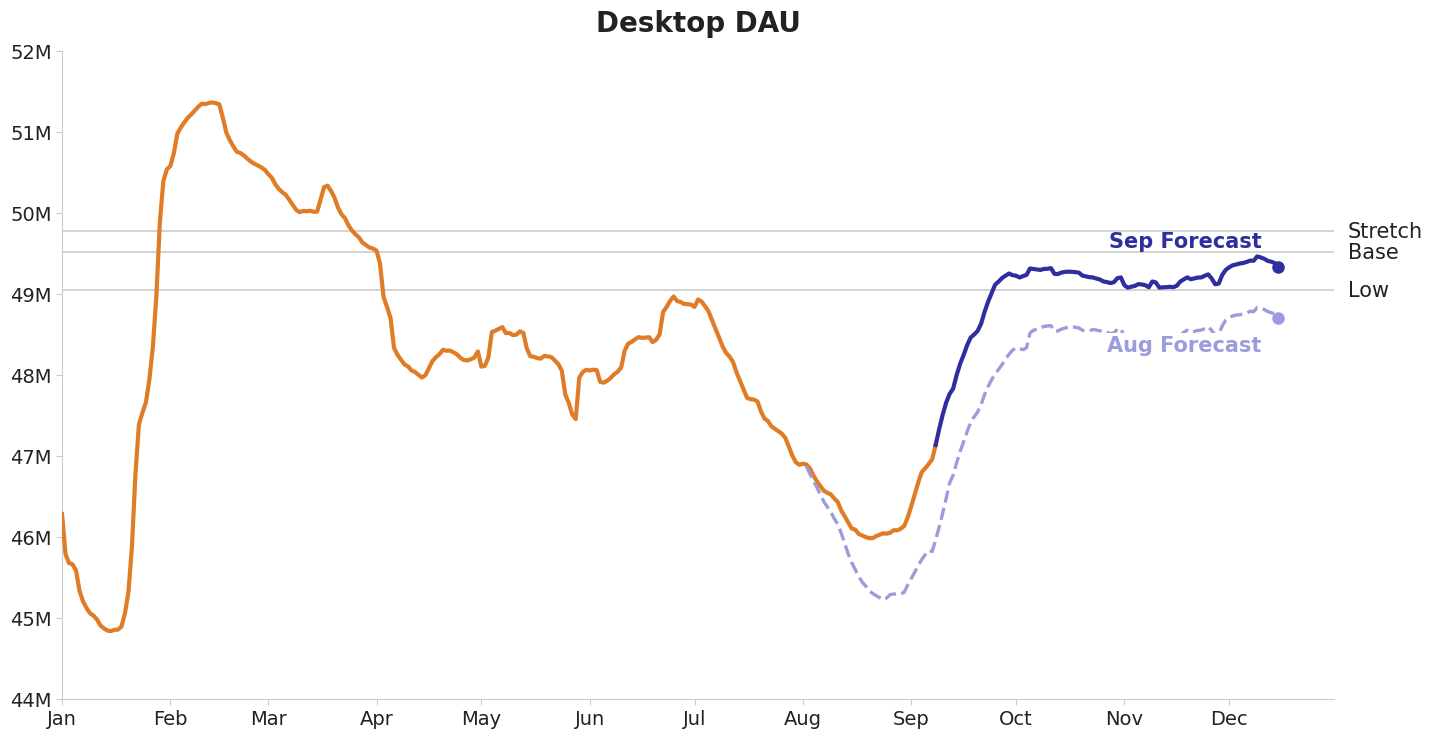

In [4]:
# [plot-desktop]
fig_desktop, _ = plot_platform("desktop", "Desktop DAU", TARGETS["desktop"])
plt.show()


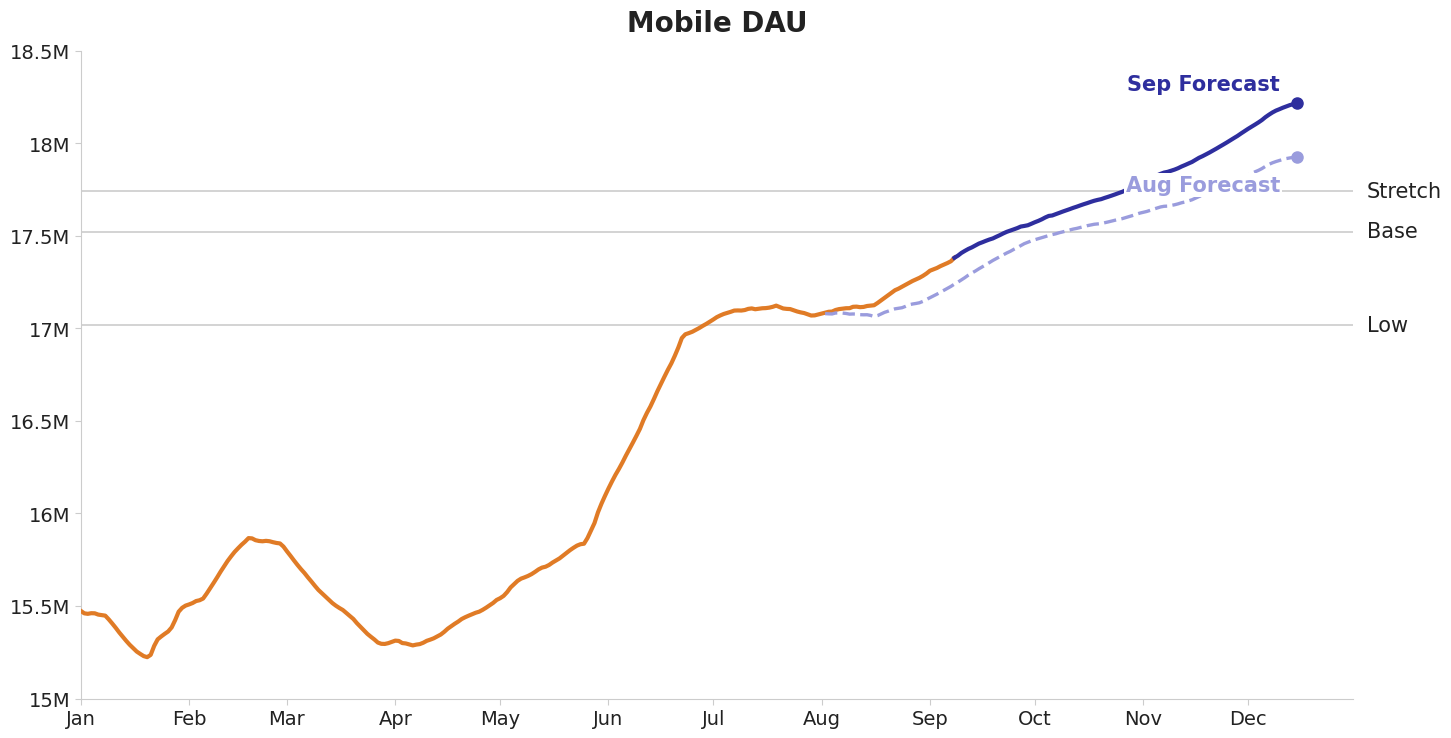

In [5]:
# [plot-mobile]
fig_mobile, _ = plot_platform("mobile", "Mobile DAU", TARGETS["mobile"])
plt.show()


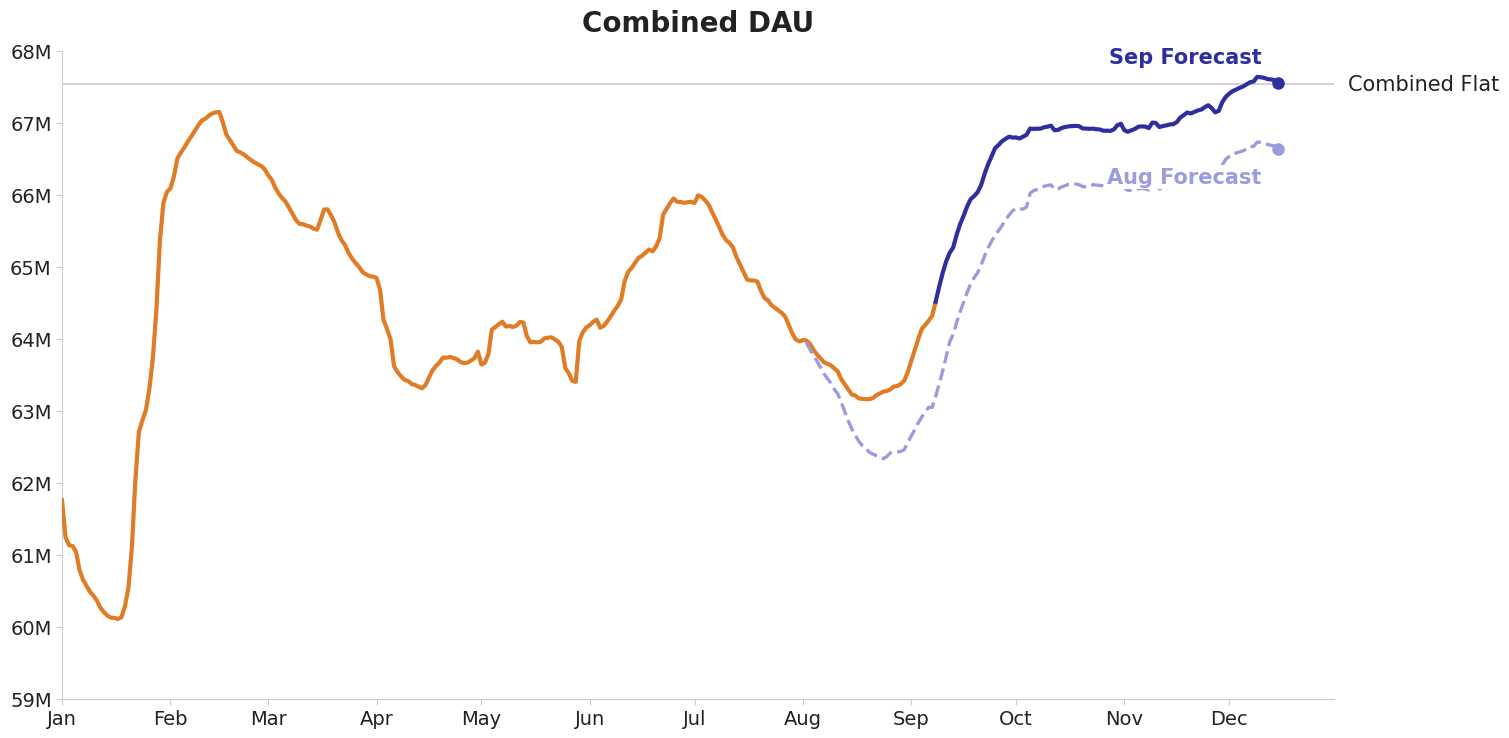

product bets hidden (SHOW_PRODUCT_BETS = False)


In [6]:
# [plot-combined]
# Combined = desktop + mobile from the CSV's all_* columns. Reference line is Combined Flat (flat YoY), and each
# product bet is drawn as forecast + ramp, shaded to the forecast, so the bet is visibly separate from the model.
s = platform_series["all"]
bet_curves = [(bet, bet_series(s["current"], bet)) for bet in (PRODUCT_BETS if SHOW_PRODUCT_BETS else [])]
extent = np.concatenate([s["actuals"].values, s["current"].values, s["prior"].values, [COMBINED_FLAT_DEC15],
                         *[c.values for _, c in bet_curves]])
fig_combined, ax = executive_axes("Combined DAU", extent)
draw_reference_line(ax, COMBINED_FLAT_DEC15, "Combined Flat", DISPLAY_END + pd.Timedelta(days=4))
ax.plot(s["actuals"].index, s["actuals"].values, color=COLOR_ACTUALS, linewidth=LINEWIDTH_MAIN, zorder=3)

dy, boxed = label_offsets(ax, s["current"], s["prior"],
                          {f"bet{i}": c for i, (_, c) in enumerate(bet_curves)},
                          reference_values=[COMBINED_FLAT_DEC15],   # keeps "Sep Forecast" off the Combined Flat line
                          labels={f"bet{i}": bet["label"] for i, (bet, _) in enumerate(bet_curves)})

draw_forecast_line(ax, s["prior"], COLOR_PRIOR, PRIOR_LABEL, linestyle="--", linewidth=LINEWIDTH_PRIOR, label_dy=dy["prior"])
for i, (bet, curve) in enumerate(bet_curves):
    ax.fill_between(curve.index, s["current"].values, curve.values, color=COLOR_BET_FILL, alpha=0.15, zorder=2)
    draw_forecast_line(ax, curve, COLOR_BET, bet["label"], linewidth=LINEWIDTH_PRIOR, label_dy=dy[f"bet{i}"], boxed=boxed[f"bet{i}"])
draw_forecast_line(ax, s["current"], COLOR_CURRENT, CURRENT_LABEL, label_dy=dy["current"], boxed=boxed["current"])
check_tick_labels(ax)
plt.show()
if not SHOW_PRODUCT_BETS:
    print("product bets hidden (SHOW_PRODUCT_BETS = False)")
for bet, curve in bet_curves:
    print(f"{bet['label']}: Dec-15 {curve.iloc[-1]:,.0f} = forecast {s['current'].iloc[-1]:,.0f} + {bet['dec15_increment']:+,.0f} (ILLUSTRATIVE unless stated)")


In [7]:
# [save-plots]
outputs = {"executive_desktop.png": fig_desktop, "executive_mobile.png": fig_mobile, "executive_combined.png": fig_combined}
for name, fig in outputs.items():
    path = PLOTS_DIR / name
    fig.savefig(path, dpi=DPI, facecolor="white")
    print(f"wrote {path}")


wrote research/executive-plot/plots/executive_desktop.png
wrote research/executive-plot/plots/executive_mobile.png
wrote research/executive-plot/plots/executive_combined.png
